# Customer Sentiment — Model Training & Comparison

Three separate modeling tasks, based on what the EDA notebook found:

1. **Sentiment classification (NLP)** — predict `sentiment` from `review_text` alone (TF-IDF + classifiers)
2. **Complaint registered** — predict from `customer_rating` + demographic/purchase context (tabular, 6 algorithms)
3. **Issue resolved** — predict from `response_time_hours` + demographic/purchase context (tabular, 6 algorithms)

Each tabular task compares: **Logistic Regression, KNN, Decision Tree, Random Forest, Gradient Boosting, XGBoost** — with a metrics table and ROC curves — and saves the best model for the Streamlit app.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

sns.set_style('whitegrid')
os.makedirs('../models', exist_ok=True)

df = pd.read_csv('../data/customer_sentiment_clean.csv')
df.shape

(25000, 12)

## Task 1 — Sentiment Classification from Review Text (NLP)

`customer_rating` would make this trivial (perfect 1:1 mapping), so this task uses **only the free-text review** as input, which is the realistic version of a sentiment-analysis problem.

In [2]:
X_text = df['review_text']
y_sent = df['sentiment']

Xtr_txt, Xte_txt, ytr_sent, yte_sent = train_test_split(
    X_text, y_sent, test_size=0.2, random_state=42, stratify=y_sent
)

tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2))
Xtr_tfidf = tfidf.fit_transform(Xtr_txt)
Xte_tfidf = tfidf.transform(Xte_txt)

text_models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC(),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
}

text_results = []
text_fitted = {}
for name, model in text_models.items():
    model.fit(Xtr_tfidf, ytr_sent)
    preds = model.predict(Xte_tfidf)
    text_results.append({
        'Model': name,
        'Accuracy': accuracy_score(yte_sent, preds),
        'Precision': precision_score(yte_sent, preds, average='macro'),
        'Recall': recall_score(yte_sent, preds, average='macro'),
        'F1 Score': f1_score(yte_sent, preds, average='macro'),
    })
    text_fitted[name] = model

text_results_df = pd.DataFrame(text_results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
text_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,1.0,1.0,1.0,1.0
1,Logistic Regression,1.0,1.0,1.0,1.0
2,Linear SVM,1.0,1.0,1.0,1.0
3,Random Forest,1.0,1.0,1.0,1.0


In [3]:
best_text_model_name = text_results_df.iloc[0]['Model']
best_text_model = text_fitted[best_text_model_name]
print('Best sentiment model:', best_text_model_name)

joblib.dump(best_text_model, '../models/sentiment_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
text_results_df.to_csv('../models/sentiment_model_comparison.csv', index=False)

Best sentiment model: Multinomial Naive Bayes


## Shared setup for the two tabular tasks

Both `complaint_registered` and `issue_resolved` use the same style of feature set: numeric + one-hot encoded categorical context. Each task drops columns that would leak the answer:
- `complaint_registered` excludes `sentiment`, `review_text`, `issue_resolved`
- `issue_resolved` excludes `sentiment`, `review_text`, `complaint_registered` is **kept** (a real complaint record existing before resolution is a legitimate, available-at-prediction-time feature)


In [4]:
def build_preprocessor(numeric_cols, categorical_cols):
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ])

def run_comparison(X, y, numeric_cols, categorical_cols, task_name):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    pre = build_preprocessor(numeric_cols, categorical_cols)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'KNN': KNeighborsClassifier(n_neighbors=15),
        'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    }

    results = []
    fitted = {}
    roc_data = {}
    le = LabelEncoder()
    ytr_enc = le.fit_transform(ytr)
    yte_enc = le.transform(yte)
    pos_label_idx = list(le.classes_).index('yes') if 'yes' in le.classes_ else 1

    for name, model in models.items():
        pipe = Pipeline([('pre', pre), ('model', model)])
        pipe.fit(Xtr, ytr_enc)
        preds = pipe.predict(Xte)
        probs = pipe.predict_proba(Xte)[:, pos_label_idx]

        fpr, tpr, _ = roc_curve(yte_enc, probs, pos_label=pos_label_idx)
        auc = roc_auc_score(yte_enc, probs)

        results.append({
            'Model': name,
            'Accuracy': accuracy_score(yte_enc, preds),
            'Precision': precision_score(yte_enc, preds, average='weighted'),
            'Recall': recall_score(yte_enc, preds, average='weighted'),
            'F1 Score': f1_score(yte_enc, preds, average='weighted'),
            'ROC-AUC': auc,
        })
        fitted[name] = pipe
        roc_data[name] = (fpr, tpr, auc)

    results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
    return results_df, fitted, roc_data, le

def plot_roc(roc_data, title):
    plt.figure(figsize=(8,6))
    for name, (fpr, tpr, auc) in roc_data.items():
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend()
    plt.show()

## Task 2 — Complaint Registered

In [5]:
numeric_cols_c = ['customer_rating', 'response_time_hours']
categorical_cols_c = ['gender', 'age_group', 'region', 'product_category', 'platform']

X_c = df[numeric_cols_c + categorical_cols_c]
y_c = df['complaint_registered']

complaint_results, complaint_fitted, complaint_roc, complaint_le = run_comparison(
    X_c, y_c, numeric_cols_c, categorical_cols_c, 'Complaint Registered'
)
complaint_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.0000,1.000000,1.0000,1.000000,1.000000
1,Decision Tree,1.0000,1.000000,1.0000,1.000000,1.000000
2,Gradient Boosting,1.0000,1.000000,1.0000,1.000000,1.000000
3,Random Forest,1.0000,1.000000,1.0000,1.000000,1.000000
4,XGBoost,1.0000,1.000000,1.0000,1.000000,1.000000
5,KNN,0.9792,0.979192,0.9792,0.979185,0.998028


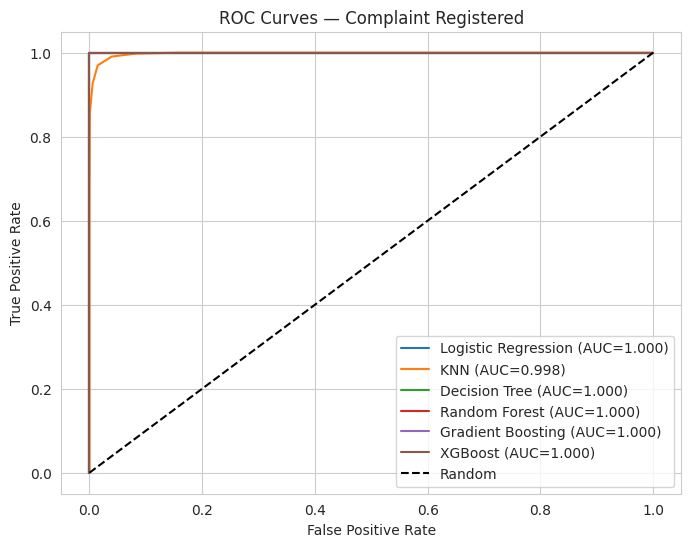

In [6]:
plot_roc(complaint_roc, 'ROC Curves — Complaint Registered')

In [7]:
best_complaint_name = complaint_results.iloc[0]['Model']
best_complaint_model = complaint_fitted[best_complaint_name]
print('Best complaint model:', best_complaint_name)

joblib.dump(best_complaint_model, '../models/complaint_model.pkl')
joblib.dump(complaint_le, '../models/complaint_label_encoder.pkl')
complaint_results.to_csv('../models/complaint_model_comparison.csv', index=False)

Best complaint model: Logistic Regression


## Task 3 — Issue Resolved

In [8]:
numeric_cols_r = ['customer_rating', 'response_time_hours']
categorical_cols_r = ['gender', 'age_group', 'region', 'product_category', 'platform', 'complaint_registered']

X_r = df[numeric_cols_r + categorical_cols_r]
y_r = df['issue_resolved']

resolved_results, resolved_fitted, resolved_roc, resolved_le = run_comparison(
    X_r, y_r, numeric_cols_r, categorical_cols_r, 'Issue Resolved'
)
resolved_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9998,0.999800,0.9998,0.999800,1.000000
1,Decision Tree,1.0000,1.000000,1.0000,1.000000,1.000000
2,Gradient Boosting,1.0000,1.000000,1.0000,1.000000,1.000000
3,Random Forest,1.0000,1.000000,1.0000,1.000000,1.000000
4,XGBoost,1.0000,1.000000,1.0000,1.000000,1.000000
5,KNN,0.9340,0.933693,0.9340,0.933664,0.984579


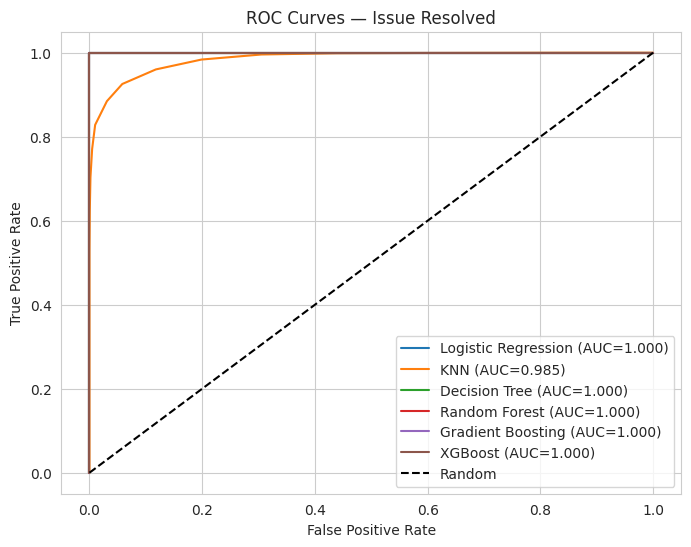

In [9]:
plot_roc(resolved_roc, 'ROC Curves — Issue Resolved')

In [10]:
best_resolved_name = resolved_results.iloc[0]['Model']
best_resolved_model = resolved_fitted[best_resolved_name]
print('Best issue-resolved model:', best_resolved_name)

joblib.dump(best_resolved_model, '../models/resolved_model.pkl')
joblib.dump(resolved_le, '../models/resolved_label_encoder.pkl')
resolved_results.to_csv('../models/resolved_model_comparison.csv', index=False)

Best issue-resolved model: Logistic Regression


## Summary

| Task | Best model | Key metric |
|---|---|---|
| Sentiment (from review text) | see table above | F1 (macro) |
| Complaint registered | see table above | ROC-AUC |
| Issue resolved | see table above | ROC-AUC |

All three best models, plus their preprocessing objects (TF-IDF vectorizer, label encoders), are saved to `../models/` for the Streamlit app.

In [11]:
summary = {
    'sentiment': {'best_model': best_text_model_name, 'metrics': text_results_df.iloc[0].to_dict()},
    'complaint_registered': {'best_model': best_complaint_name, 'metrics': complaint_results.iloc[0].to_dict()},
    'issue_resolved': {'best_model': best_resolved_name, 'metrics': resolved_results.iloc[0].to_dict()},
    'feature_config': {
        'complaint': {'numeric': numeric_cols_c, 'categorical': categorical_cols_c},
        'resolved': {'numeric': numeric_cols_r, 'categorical': categorical_cols_r},
    },
    'categorical_values': {
        'gender': sorted(df['gender'].unique().tolist()),
        'age_group': sorted(df['age_group'].unique().tolist()),
        'region': sorted(df['region'].unique().tolist()),
        'product_category': sorted(df['product_category'].unique().tolist()),
        'platform': sorted(df['platform'].unique().tolist()),
    }
}
with open('../models/model_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('Saved model_summary.json')
summary

Saved model_summary.json


{'sentiment': {'best_model': 'Multinomial Naive Bayes',
  'metrics': {'Model': 'Multinomial Naive Bayes',
   'Accuracy': 1.0,
   'Precision': 1.0,
   'Recall': 1.0,
   'F1 Score': 1.0}},
 'complaint_registered': {'best_model': 'Logistic Regression',
  'metrics': {'Model': 'Logistic Regression',
   'Accuracy': 1.0,
   'Precision': 1.0,
   'Recall': 1.0,
   'F1 Score': 1.0,
   'ROC-AUC': 1.0}},
 'issue_resolved': {'best_model': 'Logistic Regression',
  'metrics': {'Model': 'Logistic Regression',
   'Accuracy': 0.9998,
   'Precision': 0.9998000602409638,
   'Recall': 0.9998,
   'F1 Score': 0.9997999853094598,
   'ROC-AUC': 1.0}},
 'feature_config': {'complaint': {'numeric': ['customer_rating',
    'response_time_hours'],
   'categorical': ['gender',
    'age_group',
    'region',
    'product_category',
    'platform']},
  'resolved': {'numeric': ['customer_rating', 'response_time_hours'],
   'categorical': ['gender',
    'age_group',
    'region',
    'product_category',
    'platform',
